# Erstellung der Occupancy map
Ziel dieses Notebooks ist es, die vorliegenden PDF Plände in eine nutzbare Occupancy Map umzuwandeln. <br>
Die vorliegenden Pläne enthalten je zwei Stockwerke. Sie sind zunächst zu teilen. Anschließend sind Bemaßungen und Beschriftungen zu entfernen.<br>
Die resultierende Karte muss in eine binäre Grid-Map umgewandelt werden. Diese kann anschließend im Particle Filter verwendet werden.

## Import und Definition

In [1]:
import numpy as np

import matplotlib.pyplot as plt
import cv2

RESOLUTION = 0.2 # Size of each pixel in m

## EG
### Grundrissplan einlesen

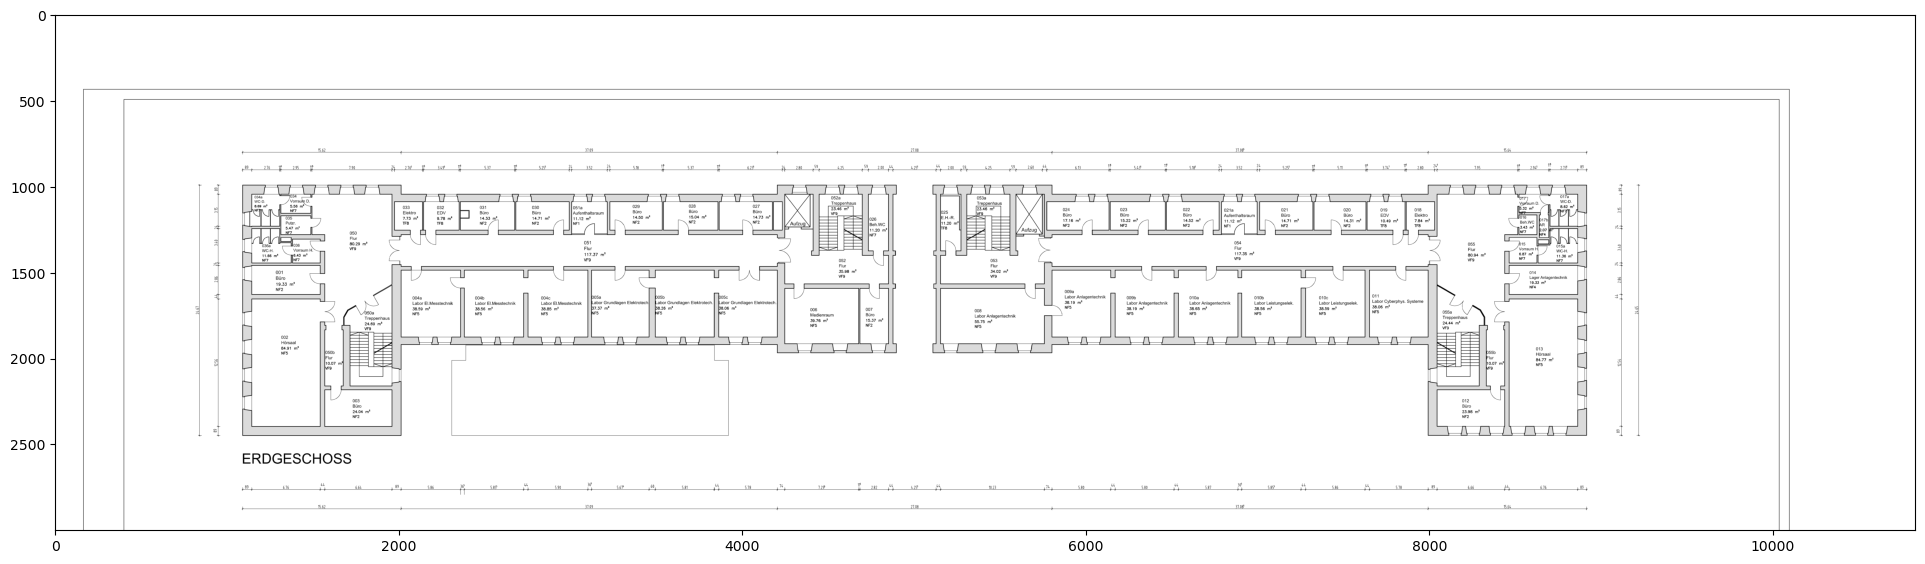

In [2]:
img= cv2.imread("../data/floorplans/05101_OTH-AM_Geb.G_GR_UG-EG_M200_13-01-2020.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(24,16))
plt.imshow(img[:3000,:], cmap='gray')

img_eg = img[:3000, :]

In [3]:
np.unique(img_eg, return_counts=True)

(array([  0,  54,  63, 109, 127, 164, 191, 219, 255], dtype=uint8),
 array([  545637,      926,    20396,    46068,   198817,      777,
           20923,  1053787, 30602669], dtype=int64))

### Mauerpixel extrahieren
Hintergrundpixel haben die Intensität 255. Mauerpixel werden durch die Pixel mit dem zweithöchsten Vorkommen (Intensität 219) repräsentiert. 

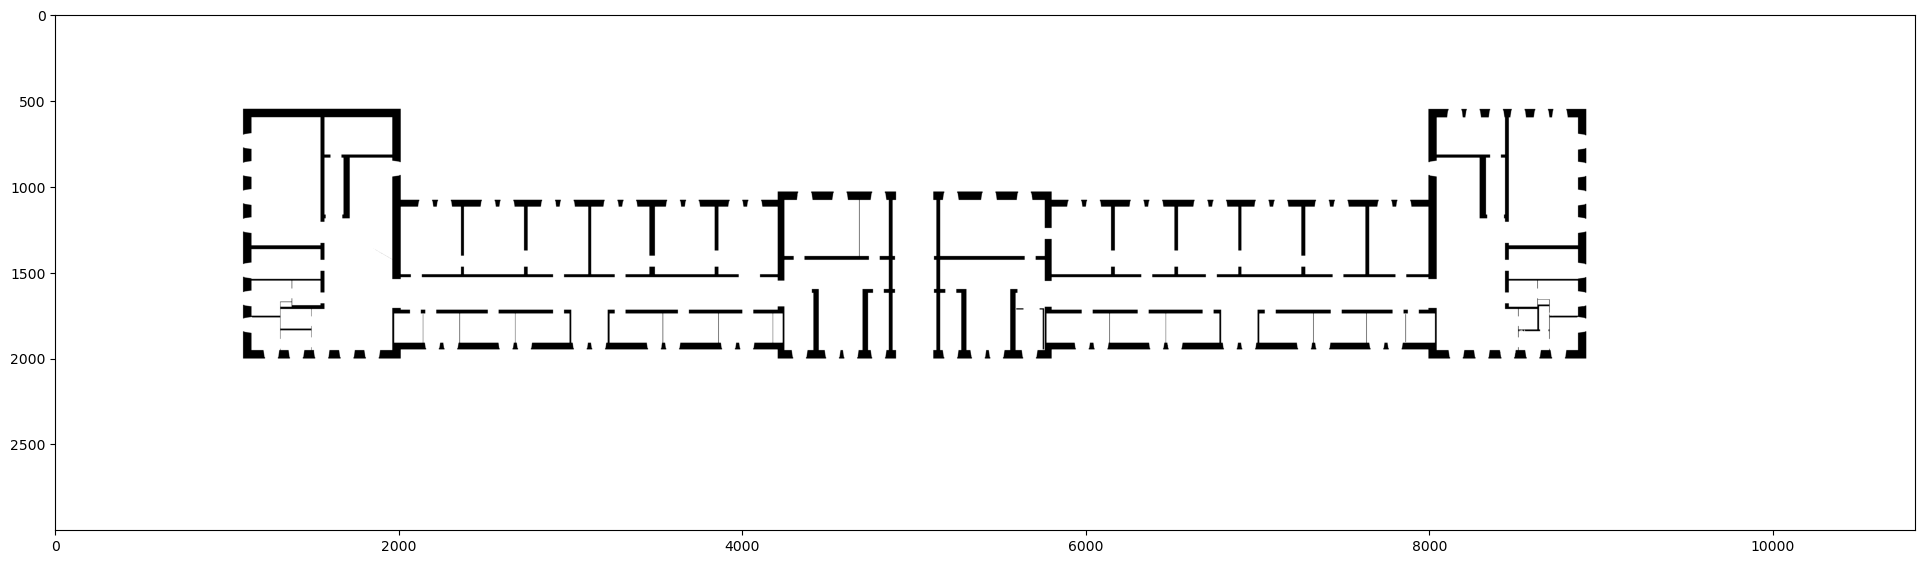

In [27]:
img_eg_filtered = np.ones_like(img_eg)
img_eg_filtered[img_eg == 219] = 0
img_eg_filtered = img_eg_filtered[::-1, ::] # Mirror at y axis to align mathematic and opencv axis

plt.figure(figsize=(24,16))
plt.imshow(img_eg_filtered, cmap='gray')

Aufgrund der Art der Extraktion der Mauerpixel liegt leichtes Rauschen vor. Dieses wird mit Closing entfernt.

In [5]:
occupancy_map_eg = cv2.morphologyEx(
    img_eg_filtered.astype(np.uint8),
    cv2.MORPH_CLOSE,
    np.ones((3,3), np.uint8)
)

Durch Opening werden Fenster- und Türlücken geschlossen.

In [6]:
kernel = np.ones((1,100), dtype=np.uint8)
kernel[0,:] = 1

occupancy_map_eg = cv2.morphologyEx(
    occupancy_map_eg.astype(np.uint8),
    cv2.MORPH_OPEN,
    kernel
)

kernel = np.ones((100,1), dtype=np.uint8)
kernel[:,0] = 1

occupancy_map_eg = cv2.morphologyEx(
    occupancy_map_eg.astype(np.uint8),
    cv2.MORPH_OPEN,
    kernel
)

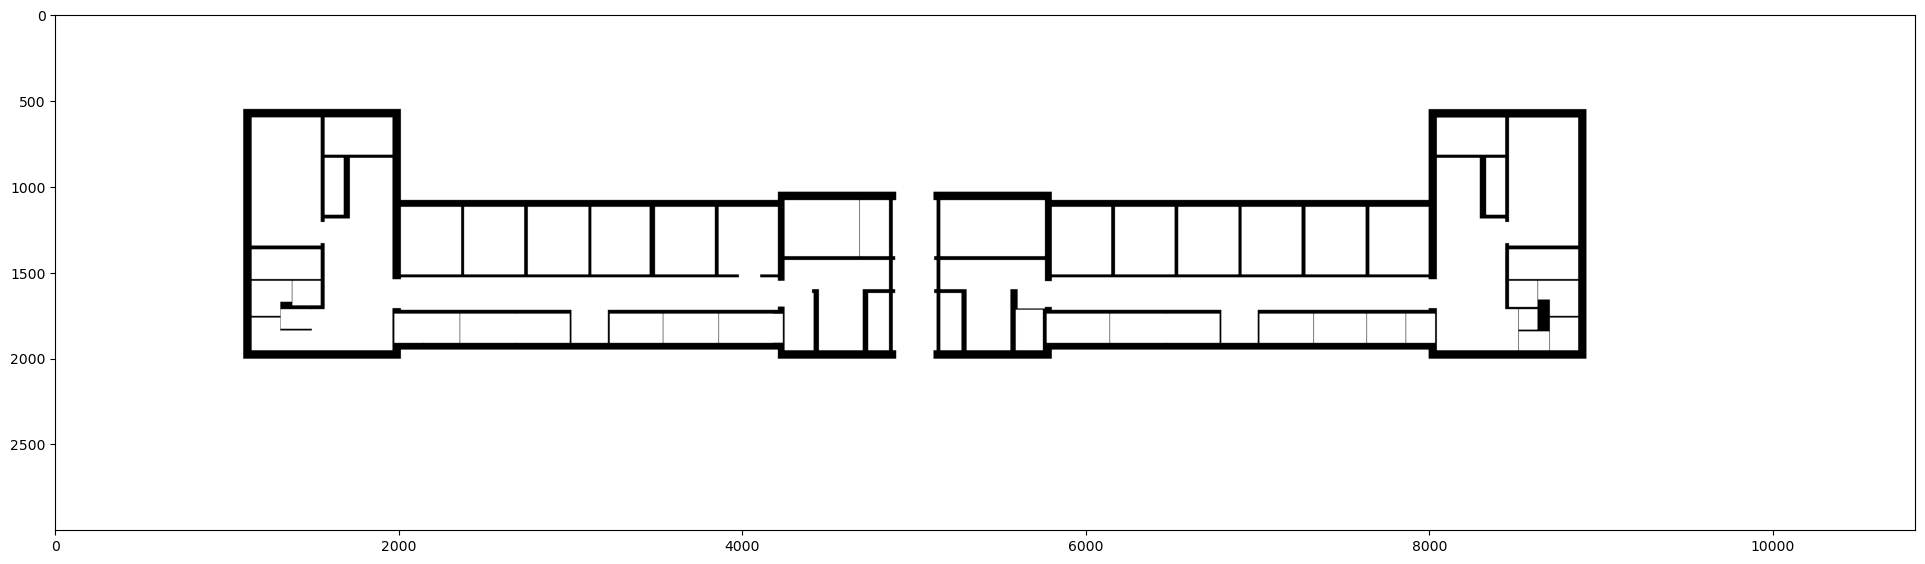

In [7]:
plt.figure(figsize=(24,16))
plt.imshow(occupancy_map_eg, cmap='gray')

### Skalierung der Map
!TODO: Durch die Skalierung gehen manche Features (dünne Wände) verloren. Hier muss nachgebessert werden

Das gesamte Gebäude hat eine Länge von $~132,5m$.

In [8]:
extent_m = 132.5

ys, xs = np.where(occupancy_map_eg == 0)

xmin = xs.min()
xmax = xs.max()

extent_px = xmax-xmin
current_res = extent_m / extent_px

print(f"Die Ausdehnung des Gebäudes in Pixeln ist {extent_px}px.")
print(f"Das ergibt eine Auflösung von {current_res}px.")

scale_factor = current_res / RESOLUTION
grid_width = int(np.round(img_eg.shape[1] * scale_factor))
grid_height = int(np.round(img_eg.shape[0] * scale_factor))

grid_height

Die Ausdehnung des Gebäudes in Pixeln ist 7820px.
Das ergibt eine Auflösung von 0.01694373401534527px.


254

In [9]:
grid_eg = cv2.resize(
    occupancy_map_eg.astype(np.uint8),
    (grid_width, grid_height),
    interpolation=cv2.INTER_NEAREST
)

ys, xs = np.where(grid_eg == 0)

xmin = xs.min()
xmax = xs.max()

extent_px = xmax-xmin
current_res = extent_m / extent_px

print(f"Länge nach Skalierung: {extent_px*current_res}")

Länge nach Skalierung: 132.5


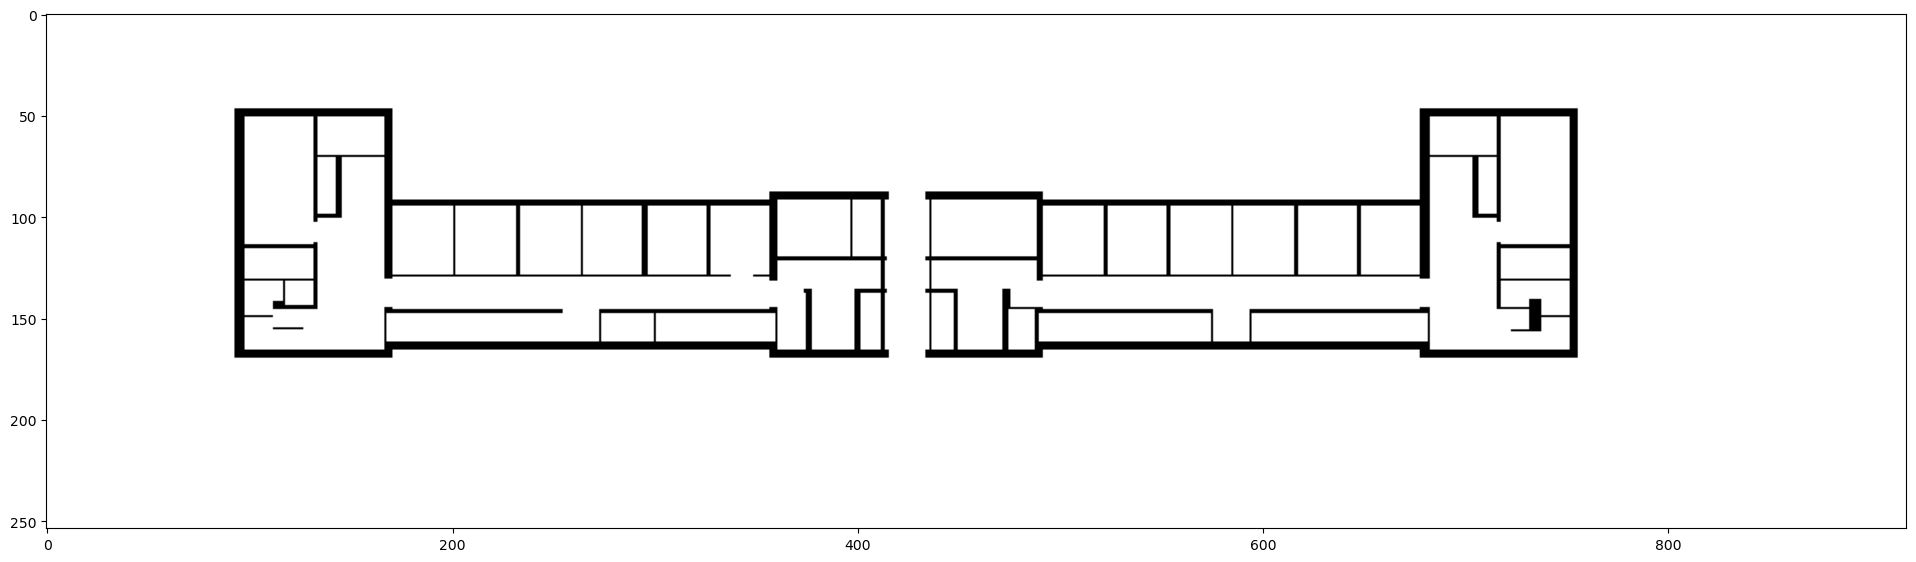

In [10]:
plt.figure(figsize=(24,16))
plt.imshow(grid_eg, cmap='gray')

### Entfernen der Whitespaces

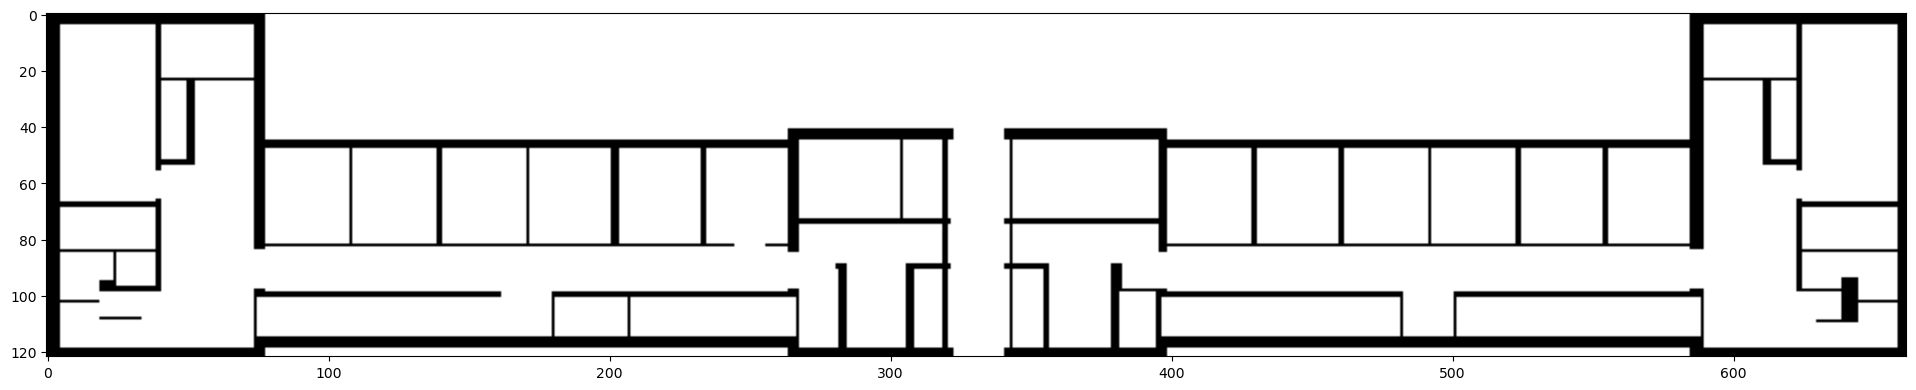

In [11]:
ys, xs = np.where(grid_eg == 0)

xmin = xs.min()
xmax = xs.max()
ymin = ys.min()
ymax = ys.max()

grid_eg_final = grid_eg[ymin:ymax, xmin:xmax]

plt.figure(figsize=(24,16))
plt.imshow(grid_eg_final, cmap='gray')

### Einfügen der Beacons

In [12]:
beacons = np.array(
    [
        [370,47,1],
        [445,40,1],
        [588,20,1],
        [590,20,0],
        [370,50,0],
        [510,40,0]
    ]
)
beacon_names = [
    'arrive_emi_1',
    'arrive_emi_2',
    'arrive_emi_3',
    'arrive_emi_4',
    'arrive_emi_8',
    'arrive_emi_10',
]

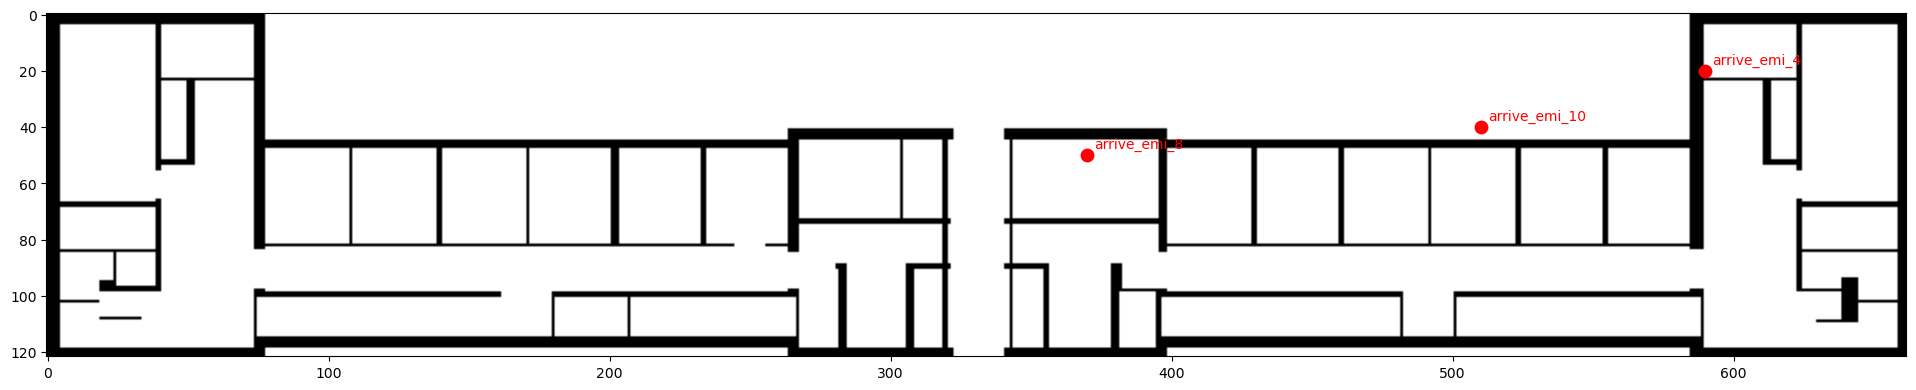

In [13]:
beacons_eg = beacons[beacons[:, 2] == 0]
names_eg = [n for n, b in zip(beacon_names, beacons) if b[2] == 0]

plt.figure(figsize=(24,16))
plt.imshow(grid_eg_final, cmap='gray')
plt.scatter(beacons_eg[:, 0], beacons_eg[:, 1], c='red', marker='o', s=80)

for name, (x, y, z) in zip(names_eg, beacons_eg):
    plt.annotate(name, (x, y), textcoords="offset points", xytext=(5, 5), color='red', fontsize=10)

plt.show()

## 1. OG
### Grundrissplan einlesen

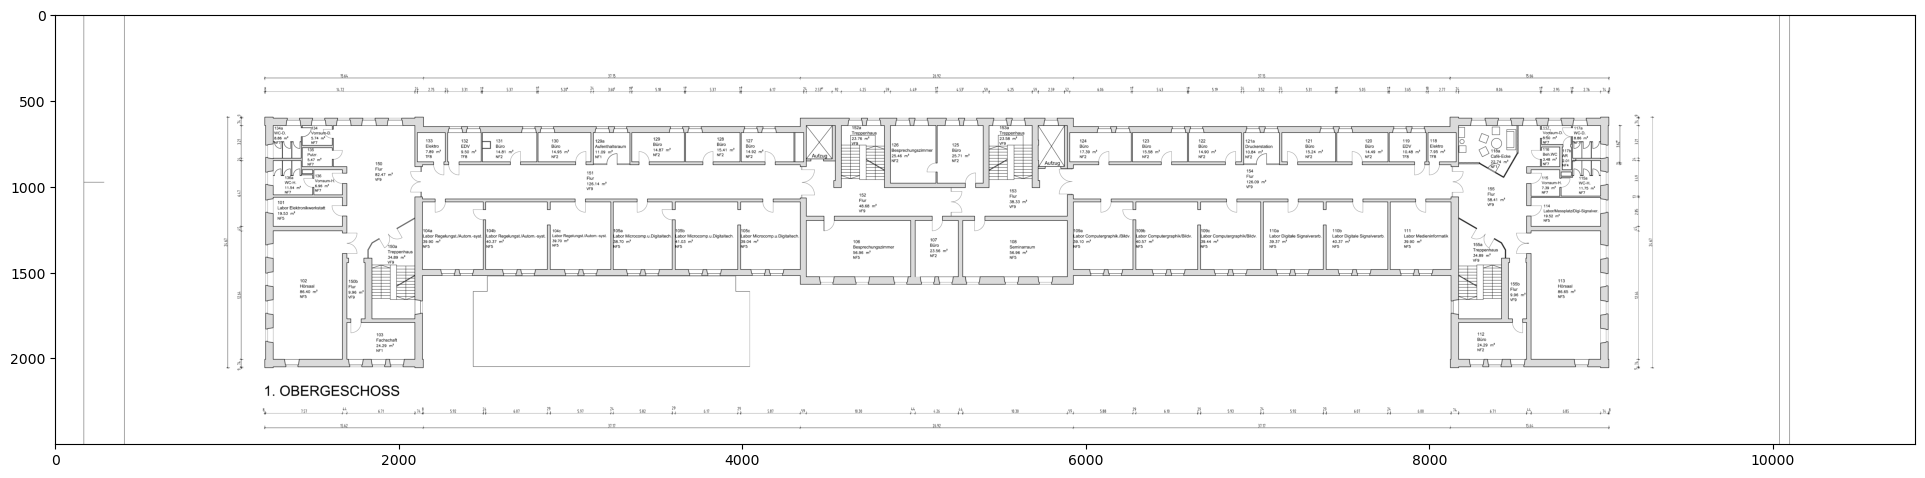

In [14]:
img = cv2.imread("../data/floorplans/05101_OTH-AM_Geb.G_GR_1OG_2OG_M200_08-03-2019.png", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(24,16))
plt.imshow(img[3000:5500,:], cmap='gray')

img_og = img[3000:5500, :]

In [15]:
np.unique(img_og, return_counts=True)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  81,  82,  83,  84,  85,  87,  88,  89,  91,  92,  94,  95,
         96,  97,  98,  99, 100, 101, 103, 104, 105, 106, 107, 108, 109,
        110, 111, 112, 113, 115, 116, 117, 118, 121, 123, 124, 125, 126,
        127, 128, 129, 130, 131, 132, 135, 136, 138, 139, 140, 141, 142,
        144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 157,
        158, 159, 161, 162, 165, 166, 167, 168, 169, 171, 172, 173, 175,
        176, 177, 178, 179, 180, 181, 183, 184, 186, 188, 189, 190, 191,
        192, 193, 195, 196, 197, 198, 199, 200, 201

### Mauerpixel extrahieren
Hintergrundpixel haben die Intensität 255. Mauerpixel werden durch die Pixel mit dem zweithöchsten Vorkommen (Intensität 219) repräsentiert. 

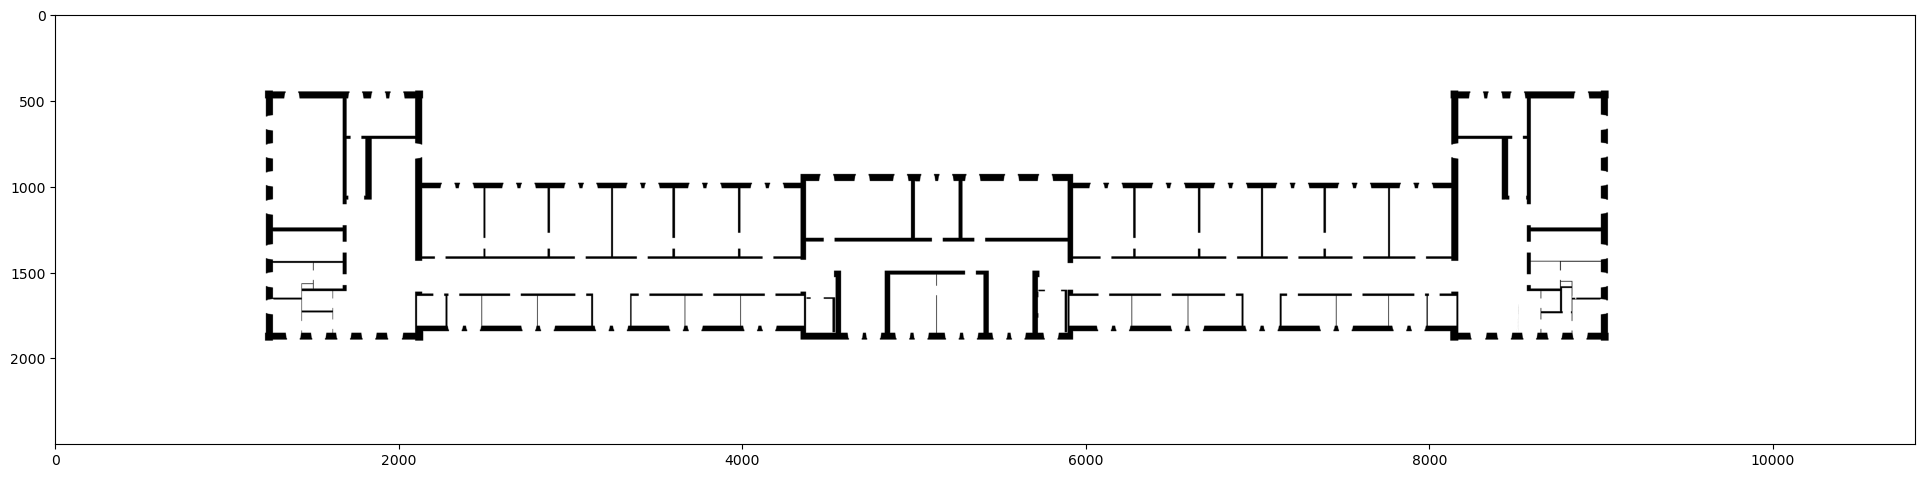

In [16]:
img_og_filtered = np.ones_like(img_og)
img_og_filtered[img_og == 219] = 0
img_og_filtered = img_og_filtered[::-1, ::] # Mirror at y axis to align mathematic and opencv axis


plt.figure(figsize=(24,16))
plt.imshow(img_og_filtered, cmap='gray')

Aufgrund der Art der Extraktion der Mauerpixel liegt leichtes Rauschen vor. Dieses wird mit Closing entfernt.

In [17]:
occupancy_map_og = cv2.morphologyEx(
    img_og_filtered.astype(np.uint8),
    cv2.MORPH_CLOSE,
    np.ones((3,3), np.uint8)
)

Durch Opening werden Fenster- und Türlücken geschlossen.

In [18]:
kernel = np.ones((1,100), dtype=np.uint8)
kernel[0,:] = 1

occupancy_map_og = cv2.morphologyEx(
    occupancy_map_og.astype(np.uint8),
    cv2.MORPH_OPEN,
    kernel
)

kernel = np.ones((100,1), dtype=np.uint8)
kernel[:,0] = 1

occupancy_map_og = cv2.morphologyEx(
    occupancy_map_og.astype(np.uint8),
    cv2.MORPH_OPEN,
    kernel
)

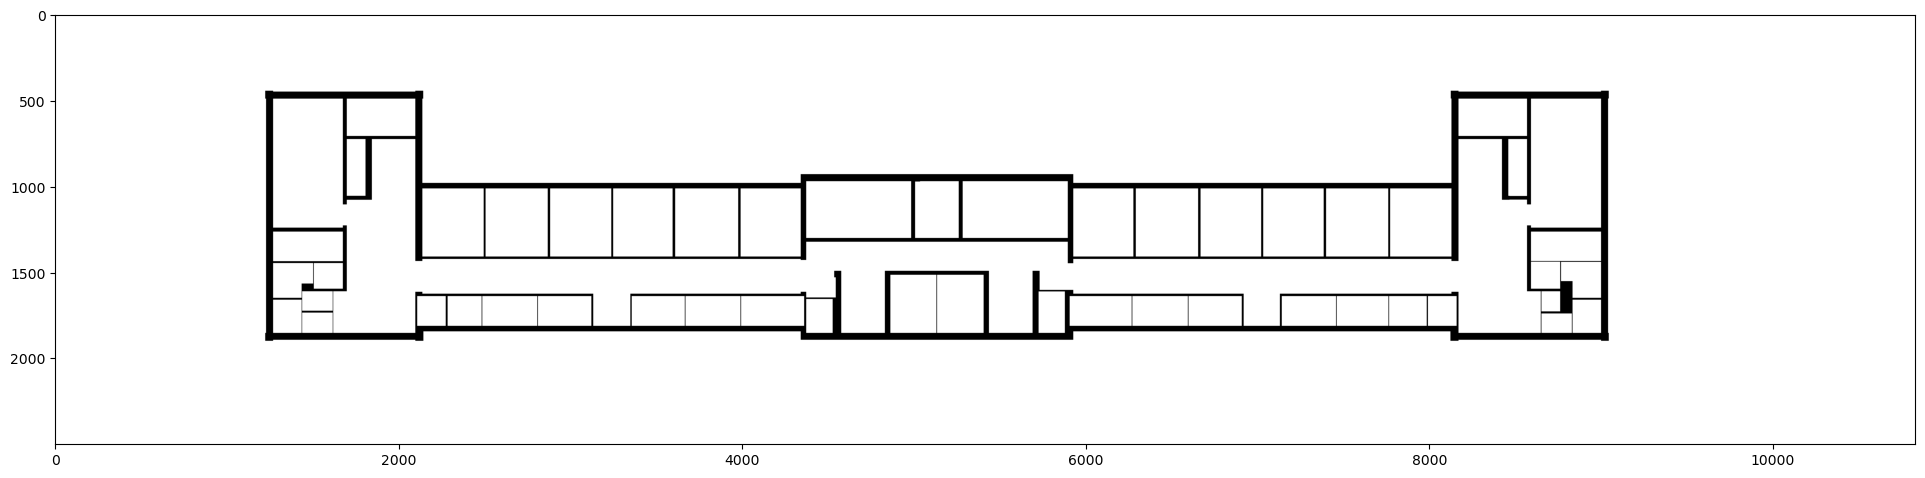

In [19]:
plt.figure(figsize=(24,16))
plt.imshow(occupancy_map_og, cmap='gray')

### Skalierung der Map
!TODO: Durch die Skalierung gehen manche Features (dünne Wände) verloren. Hier muss nachgebessert werden

Das gesamte Gebäude hat eine Länge von $~132,5m$.

In [20]:
extent_m = 132.5

ys, xs = np.where(occupancy_map_og == 0)

xmin = xs.min()
xmax = xs.max()

extent_px = xmax-xmin
current_res = extent_m / extent_px

print(f"Die Ausdehnung des Gebäudes in Pixeln ist {extent_px}px.")
print(f"Das ergibt eine Auflösung von {current_res}px.")

scale_factor = current_res / RESOLUTION
grid_width = int(np.round(img_og.shape[1] * scale_factor))
grid_height = int(np.round(img_og.shape[0] * scale_factor))

scale_factor

Die Ausdehnung des Gebäudes in Pixeln ist 7822px.
Das ergibt eine Auflösung von 0.016939401687547942px.


0.08469700843773971

Zu dünne Wände gehen beim Downscaling verloren, daher werden alle Wänder zuvor auf eine Mindestdicke von 1/scale_factor verbreitert.

In [21]:
grid_og = cv2.resize(
    occupancy_map_og.astype(np.uint8),
    (grid_width, grid_height),
    interpolation=cv2.INTER_CUBIC
)

ys, xs = np.where(grid_og == 0)

xmin = xs.min()
xmax = xs.max()

extent_px = xmax-xmin
current_res = extent_m / extent_px

print(f"Länge nach Skalierung: {extent_px*current_res}")

Länge nach Skalierung: 132.5


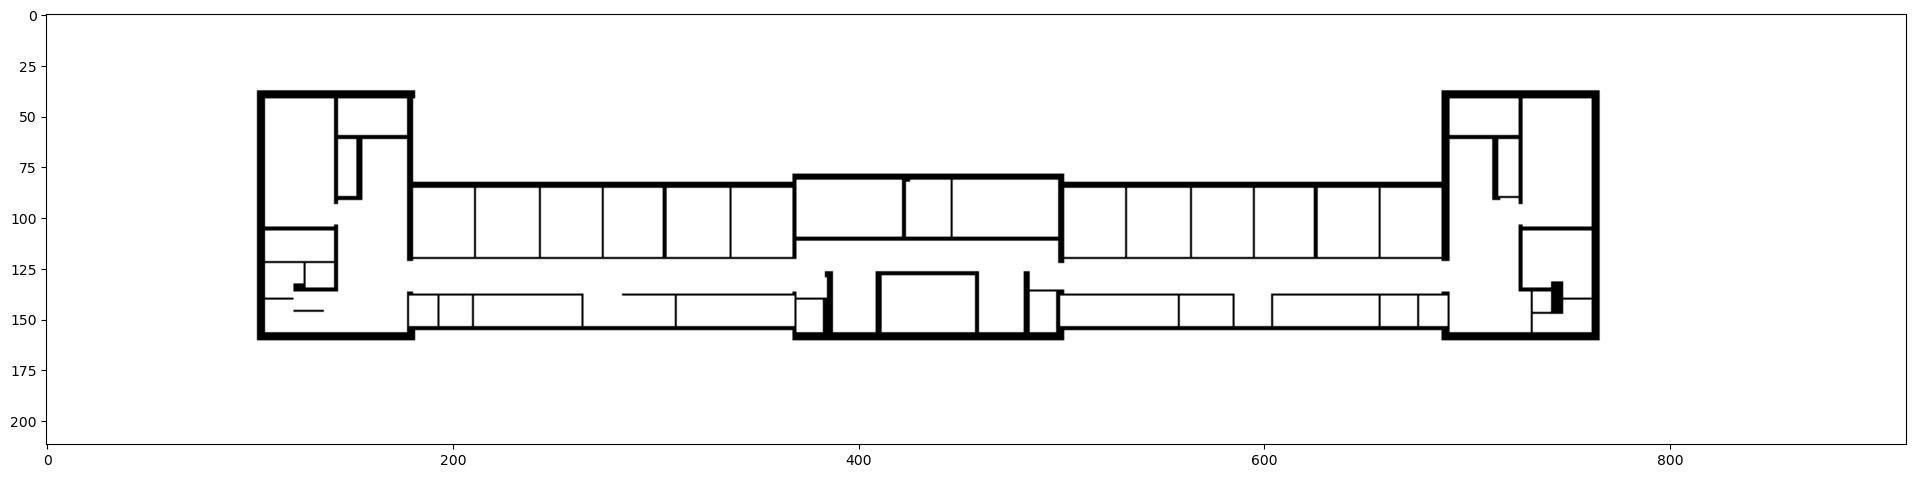

In [22]:
plt.figure(figsize=(24,16))
plt.imshow(grid_og, cmap='gray')

### Entfernen der Whitespaces

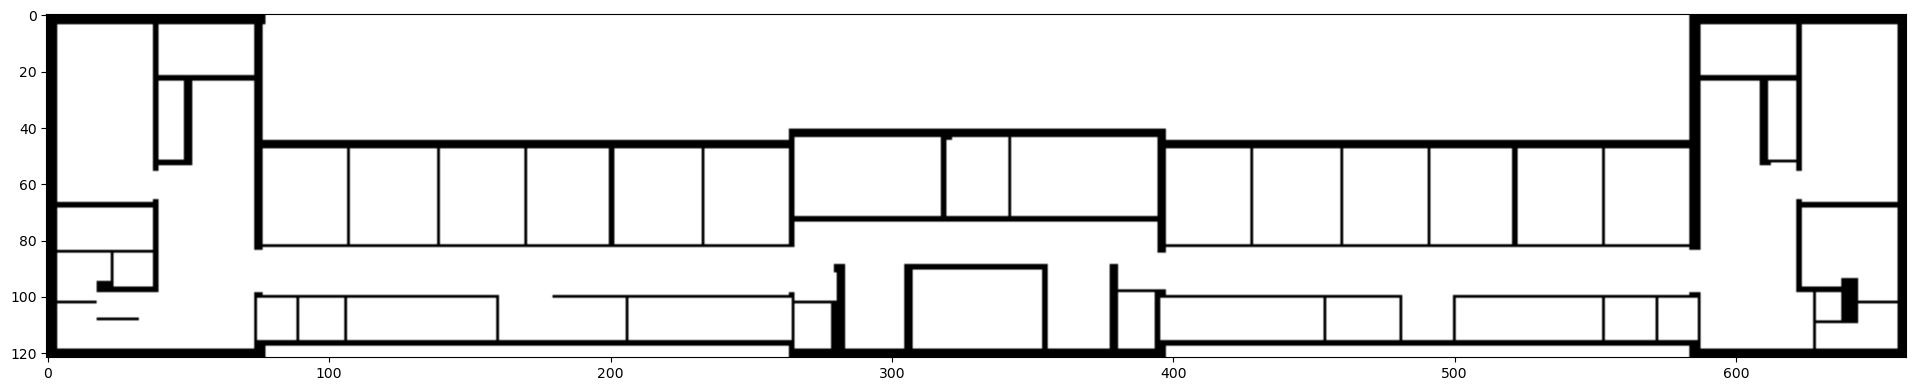

In [23]:
ys, xs = np.where(grid_og == 0)

xmin = xs.min()
xmax = xs.max()
ymin = ys.min()
ymax = ys.max()

grid_og_final = grid_og[ymin:ymax, xmin:xmax]

plt.figure(figsize=(24,16))
plt.imshow(grid_og_final, cmap='gray')

### Einfügen der Beacons

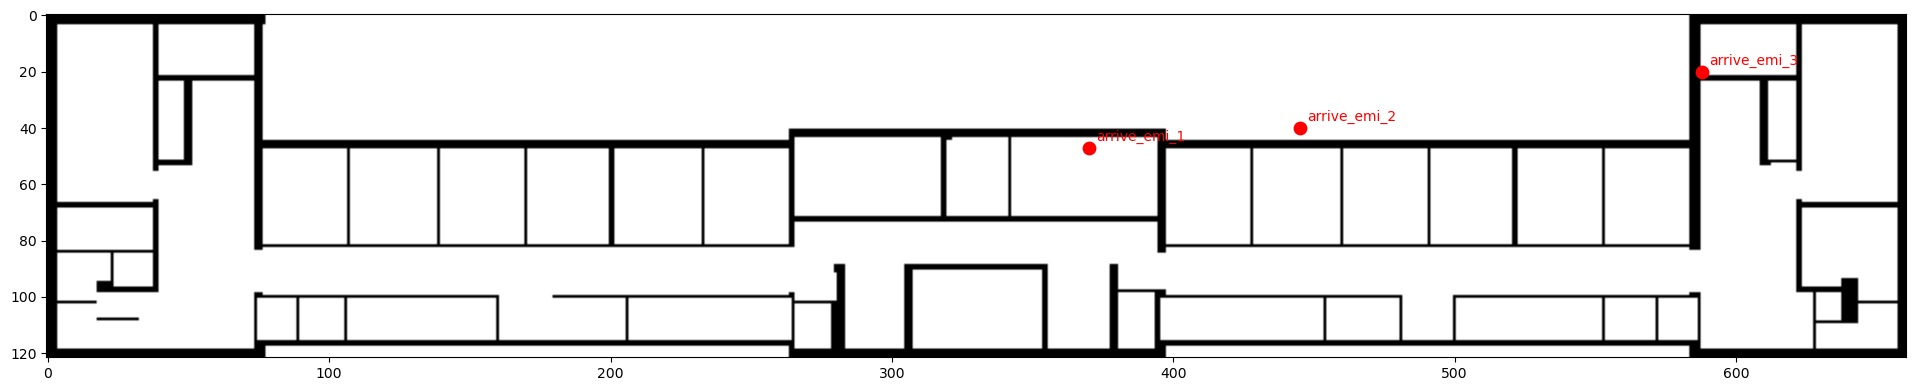

In [24]:
beacons_og = beacons[beacons[:, 2] == 1]
names_og = [n for n, b in zip(beacon_names, beacons) if b[2] == 1]

plt.figure(figsize=(24,16))
plt.imshow(grid_og_final, cmap='gray')
plt.scatter(beacons_og[:, 0], beacons_og[:, 1], c='red', marker='o', s=80)

for name, (x, y, z) in zip(names_og, beacons_og):
    plt.annotate(name, (x, y), textcoords="offset points", xytext=(5, 5), color='red', fontsize=10)

plt.show()

## Save the maps

In [25]:
np.save(r'..\data\floorplans\eg.npy', grid_eg_final, allow_pickle=True)
np.save(r'..\data\floorplans\og1.npy', grid_og_final, allow_pickle=True)